In [1]:
import numpy as np
from pathlib import Path

from fontTools.diff import color
import matplotlib.pyplot as plt
from numpy.ma.core import size

DATA_DIR = Path(r"C:\Users\asus\PycharmProjects\UltrasonicProject_ML\data")

data = np.load(
    DATA_DIR / "Pk050_3D_Dataset_Long_Rot00.npy",
    mmap_mode="r"
)

X = np.load(DATA_DIR / "X-values.npy")
Y = np.load(DATA_DIR / "Y-values.npy")
Z = np.load(DATA_DIR / "Z-values.npy")

valid_mask = np.any(data != 0, axis=2)

## Get features

In [2]:
points = {
    (250, 60): 571.3,
    (750, 60): 452.0,
    (1250, 60): 330.9,
    (1750, 60): 210.8
}

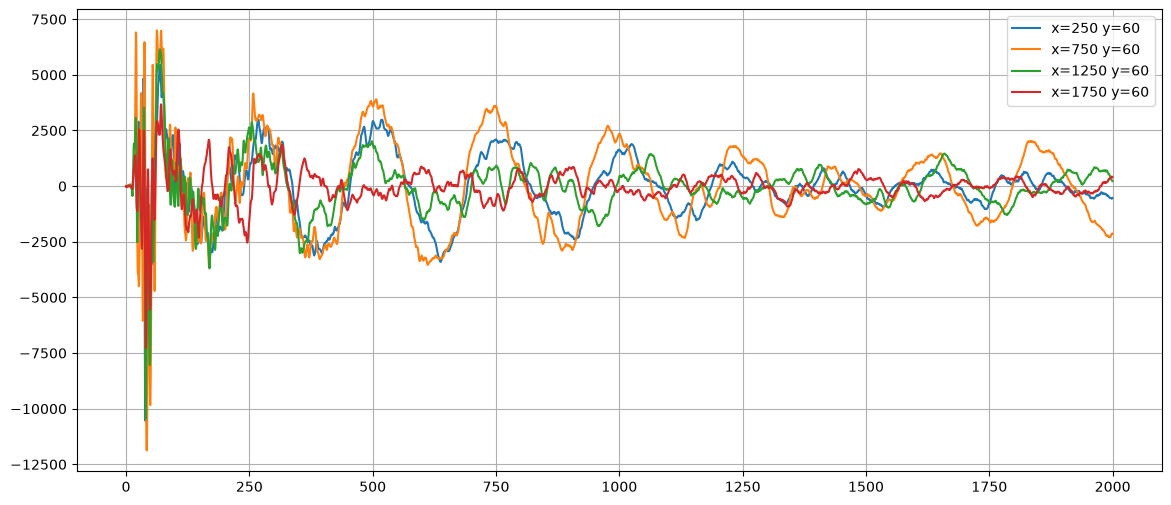

In [3]:
plt.figure(figsize=(14, 6))
for x, y in points:
    x_index = np.where( X == x )[0][0]
    y_index = np.where( Y == y )[0][0]
    a_scan = data[x_index, y_index, :]
    plt.plot(Z , a_scan, label=f'x={x} y={y}')
plt.grid()
plt.legend()
plt.savefig('a_scan.png')
plt.show()

## Butterworth Band-pass

In [4]:
import numpy as np
from scipy.signal import butter, sosfiltfilt


def butterworth_bandpass(signal, fs, lowcut, highcut, order=4):
    """
    اعمال فیلتر Butterworth Band-pass روی سیگنال.

    Parameters
    ----------
    signal : array-like
        سیگنال ورودی

    fs : float
        نرخ نمونه‌برداری بر حسب Hz

    lowcut : float
        فرکانس قطع پایین بر حسب Hz

    highcut : float
        فرکانس قطع بالا بر حسب Hz

    order : int
        مرتبه فیلتر

    Returns
    -------
    filtered_signal : numpy.ndarray
        سیگنال فیلترشده
    """

    signal = np.asarray(signal, dtype=float)

    nyquist = fs / 2

    if lowcut <= 0:
        raise ValueError("lowcut باید بزرگ‌تر از صفر باشد.")

    if highcut >= nyquist:
        raise ValueError("highcut باید کمتر از فرکانس Nyquist باشد.")

    if lowcut >= highcut:
        raise ValueError("lowcut باید کمتر از highcut باشد.")

    sos = butter(
        order,
        [lowcut, highcut],
        btype="bandpass",
        fs=fs,
        output="sos"
    )

    filtered_signal = sosfiltfilt(sos, signal)

    return filtered_signal

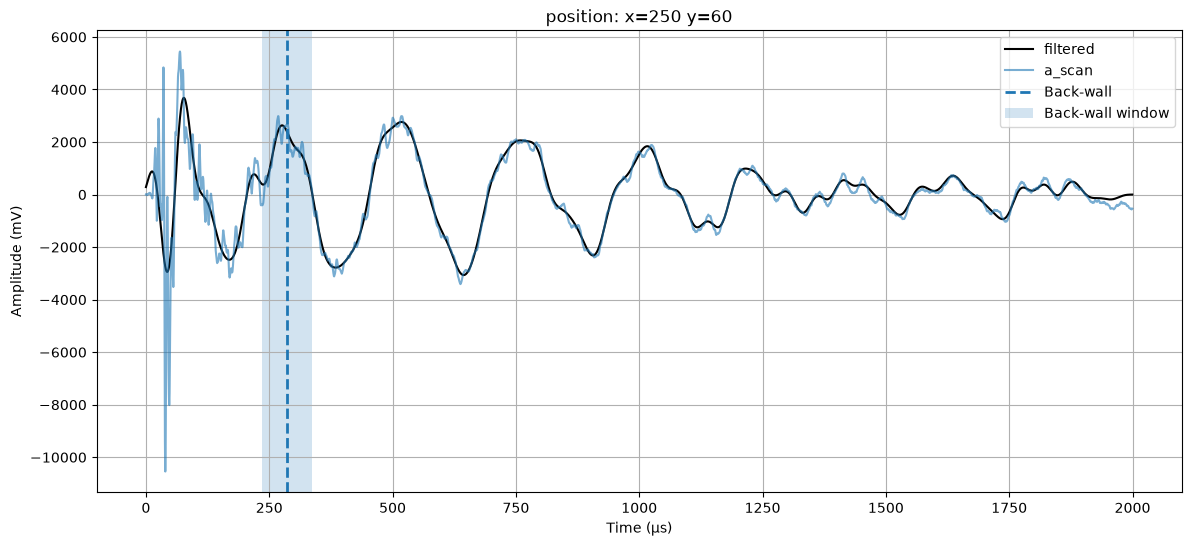

In [20]:
fs = 2e6       # 2 MHz sampling rate
a_scan = data[25, 6, :]

filtered = butterworth_bandpass(
    a_scan,
    fs=2e6,
    lowcut=0.002e6,
    highcut=0.02e6
)


plt.figure(figsize=(14, 6))
plt.plot(Z, filtered, label='filtered', color='black')
plt.plot(Z, a_scan, label='a_scan', alpha= 0.6)

t_backwall = 285.65

plt.axvline(
    x=t_backwall,
    linestyle='--',
    linewidth=2,
    label='Back-wall'
)

plt.axvspan(
    t_backwall - 50,
    t_backwall + 50,
    alpha=0.2,
    label='Back-wall window'
)

plt.grid()

plt.title('position: x=250 y=60')
plt.xlabel('Time (µs)')
plt.ylabel('Amplitude (mV)')
plt.legend()

plt.savefig('a_scan.png')
plt.show()

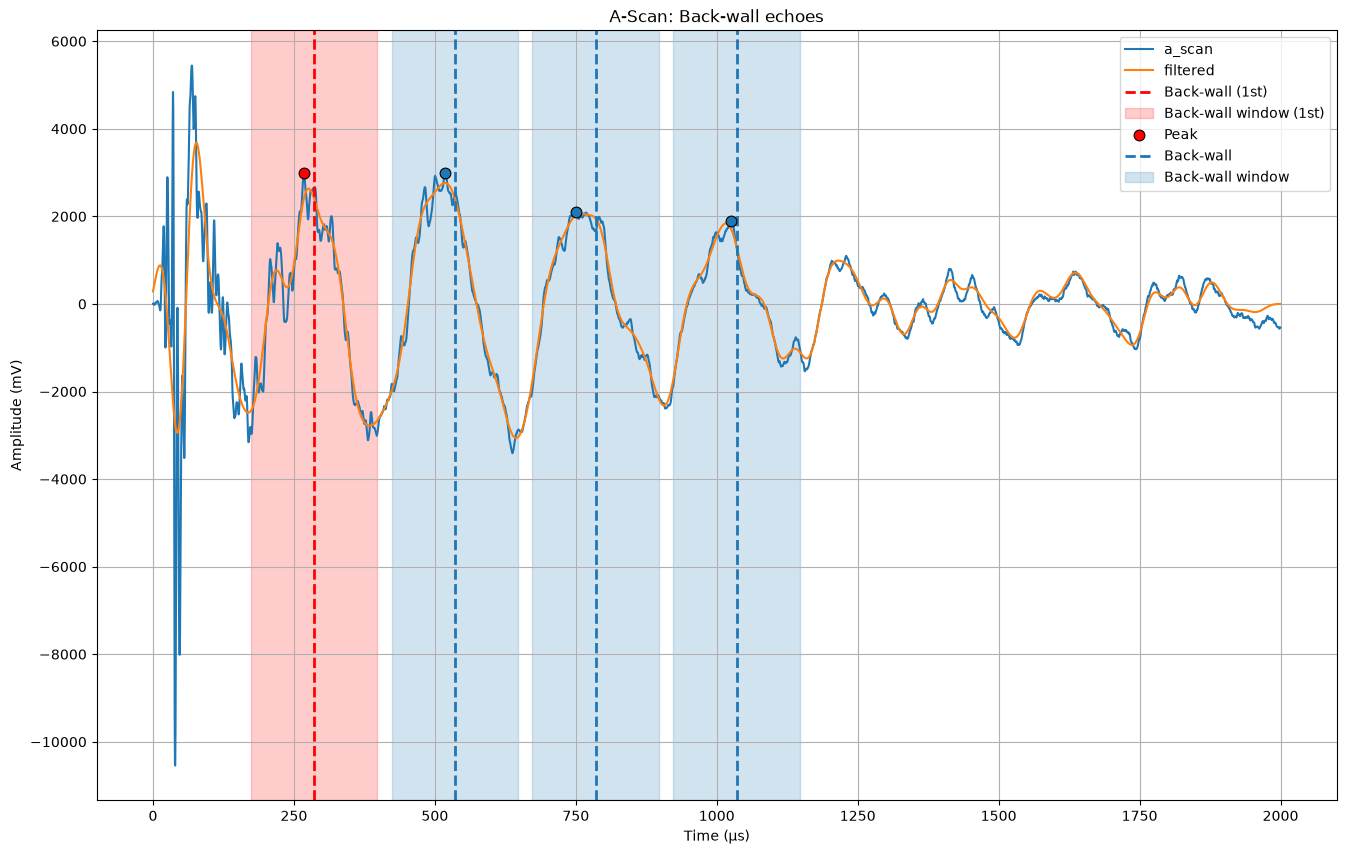

In [19]:
# -----------------------------
# Back-wall echo parameters
# -----------------------------
a_scan = data[25, 6, :]
time_us = Z
first_backwall = 285.65   # µs
echo_spacing = 250.0      # µs
window_width = 45         # samples

# Sampling rate
fs = 2_000_000            # Hz
Ts = 1 / fs               # seconds
Ts_us = Ts * 1e6          # 0.5 µs

# 20 samples = 10 µs total width
window_time = window_width * Ts_us
half_window = window_time / 2

# فقط ۴ اکو اول را می‌خواهیم (اولی قرمز، سه‌تای بعدی رنگ عادی)
n_echoes = 4

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(16, 10))
plt.plot(time_us, a_scan, label='a_scan')
plt.plot(time_us, filtered, label='filtered')

# -----------------------------
# Mark first n_echoes Back-wall echoes
# -----------------------------
for echo_number in range(1, n_echoes + 1):
    backwall_time = first_backwall + (echo_number - 1) * echo_spacing

    # رنگ: اولی قرمز، بقیه آبی پیش‌فرض
    color = 'red' if echo_number == 1 else 'tab:blue'

    # خط Back-wall
    plt.axvline(
        x=backwall_time,
        color=color,
        linestyle='--',
        linewidth=2,
        label='Back-wall (1st)' if echo_number == 1 else ('Back-wall' if echo_number == 2 else None)
    )

    # هاله اطراف Back-wall
    win_start = backwall_time - half_window * 10
    win_end = backwall_time + half_window * 10

    plt.axvspan(
        win_start,
        win_end,
        color=color,
        alpha=0.2,
        label='Back-wall window (1st)' if echo_number == 1 else ('Back-wall window' if echo_number == 2 else None)
    )

    # -----------------------------
    # پیدا کردن نقطه پیک داخل این هاله
    # -----------------------------
    mask = (time_us >= win_start) & (time_us <= win_end)
    if np.any(mask):
        window_times = time_us[mask]
        window_vals = a_scan[mask]

        peak_idx = np.argmax(window_vals)  # پیک بر اساس بیشترین دامنه (مثبت یا منفی)
        peak_time = window_times[peak_idx]
        peak_val = window_vals[peak_idx]

        plt.scatter(
            peak_time,
            peak_val,
            color=color,
            marker='o',
            s=60,
            zorder=5,
            edgecolor='black',
            linewidth=0.8,
            label='Peak' if echo_number == 1 else None
        )

plt.xlabel('Time (µs)')
plt.ylabel('Amplitude (mV)')
plt.title('A-Scan: Back-wall echoes')
plt.legend()
plt.grid()
plt.savefig('a_scan__1.png')
plt.show()

In [25]:
def get_backwall_echoes(x_idx, y_idx, first_backwall, half_window=50, max_echoes=3):
    """
    ورودی:
        x_idx, y_idx      : موقعیت A-scan مورد نظر در آرایه data
        first_backwall    : زمان اولین بک‌وال (بر حسب همون واحد time_us)
        half_window       : نیم‌پنجره‌ی برش نهایی حول هر هاله
        max_echoes        : حداکثر تعداد هاله برای استخراج
    خروجی:
        دیکشنری {'echo_1': (time_window, signal_window), ...}
    """
    signal = data[x_idx, y_idx, :]
    echoes = {}

    for n in range(1, max_echoes + 1):
        approx_center = n * first_backwall

        # پنجره‌ی جستجوی محلی (بزرگ‌تر از half_window نهایی) حول تخمین اولیه
        search_mask = (time_us >= approx_center - 2*half_window) & \
                      (time_us <= approx_center + 2*half_window)
        search_sig, search_t = signal[search_mask], time_us[search_mask]

        if len(search_sig) == 0:
            break

        # پیدا کردن پیک واقعی (بیشترین قدرمطلق دامنه) در بازه‌ی جستجو
        peak_idx = np.argmax(search_sig)
        real_center = search_t[peak_idx]   # <-- زمان پیک، نه دامنه‌ش

        # برش نهایی حول زمان پیک واقعی
        final_mask = (time_us >= real_center - half_window) & \
                     (time_us <= real_center + half_window)
        sig_win, t_win = signal[final_mask], time_us[final_mask]

        if len(t_win) == 0:
            break

        echoes[f'echo_{n}'] = (t_win, sig_win)

    return echoes

In [26]:
import numpy as np

def oscillation_ratio(signal, time, window_size=100, metric='std'):
    """
    نسبت نوسان بازه‌ی زمانی اول (به طول window_size) به میانگین نوسان
    بازه‌های زمانی بعدی را محاسبه می‌کند.

    Parameters
    ----------
    signal : array-like
        مقادیر سیگنال (مثلاً a_scan یا filtered).
    time : array-like
        آرایه‌ی زمان متناظر با signal (مثلاً Z، واحد µs).
    window_size : float, default=100
        طول هر بازه‌ی زمانی بر حسب واحد آرایه‌ی time.
    metric : {'ptp', 'std'}, default='ptp'
        معیار نوسان:
        - 'ptp': دامنه‌ی پیک‌تاپیک (max - min)
        - 'std': انحراف معیار

    Returns
    -------
    ratio : float
        نسبت نوسان بازه‌ی اول به میانگین نوسان بازه‌های بعدی.
    first_window_value : float
        مقدار نوسان بازه‌ی اول.
    other_windows_mean : float
        میانگین نوسان بازه‌های بعدی.
    """
    signal = np.asarray(signal)
    time = np.asarray(time)

    if signal.shape != time.shape:
        raise ValueError("signal و time باید هم‌طول باشند.")

    t_start = time[0]
    t_end = time[-1]

    # ساخت مرزهای بازه‌ها
    edges = np.arange(t_start, t_end + window_size, window_size)

    def compute_metric(segment):
        if metric == 'ptp':
            return np.ptp(segment)
        elif metric == 'std':
            return np.std(segment)
        else:
            raise ValueError("metric باید 'ptp' یا 'std' باشد.")

    window_values = []
    for i in range(len(edges) - 1):
        mask = (time >= edges[i]) & (time < edges[i + 1])
        segment = signal[mask]
        if segment.size > 0:
            window_values.append(compute_metric(segment))

    if len(window_values) < 2:
        raise ValueError("داده برای محاسبه‌ی حداقل دو بازه کافی نیست.")

    first_window_value = window_values[0]
    other_windows_mean = np.mean(window_values[1:])

    ratio = first_window_value / other_windows_mean

    return ratio, first_window_value, other_windows_mean

In [28]:
import ipywidgets as widgets
from ipywidgets import interact

def plot_a_scan(x, y):
    a_scan = data[x, y, :]
    plt.figure(figsize=(16, 10))

    filtered = butterworth_bandpass(
        a_scan,
        fs=2e6,
        lowcut=0.002e6,
        highcut=0.02e6
    )

    echoes = get_backwall_echoes(
        x_idx=x, y_idx=y,
        first_backwall=285.65,
        half_window= 30
    )

    plt.plot(Z, a_scan, label='a_scan', color='gray', alpha=0.6)
    plt.plot(Z, filtered, label='filtered', color='black')

    for i in echoes:
        plt.plot(echoes[i][0], echoes[i][1], label=f'{i}', linewidth=3, )  # color='red'

    plt.xlabel('Time (µs)')
    plt.ylabel('Amplitude (mV)')
    plt.title(f'A-Scan: Back-wall echoes (x={x}, y={y})')
    plt.legend()
    plt.grid()
    signal = a_scan = data[x, y, :] ; time = Z
    ratio_std, first_std, other_std = oscillation_ratio(signal, time)
    print(f'ratio_std:{ratio_std}, first_std:{first_std}, other_std:{other_std}')
    plt.show()


# اسلایدر برای x و y
interact(
    plot_a_scan,
    x=widgets.IntSlider(min=0, max=data.shape[0]-1, step=1, value=12),
    y=widgets.IntSlider(min=0, max=data.shape[1]-1, step=1, value=25)
);

interactive(children=(IntSlider(value=12, description='x', max=200), IntSlider(value=25, description='y', max=…

In [10]:
import numpy as np

def echo_periodicity_autocorr(signal, time, min_period=100, max_period=800):
    """
    تخمین دوره‌ی تناوب بین اکوهای متوالی با استفاده از خودهمبستگی (autocorrelation)
    سیگنال، و اندازه‌گیری قدرت این تناوب.

    ایده: اگر سیگنال شامل چند بک‌وال اکو با فاصله‌ی زمانی تقریباً یکسان باشد،
    تابع خودهمبستگی در آن فاصله (lag) یک پیک برجسته خواهد داشت. ارتفاع نسبی
    این پیک نشان می‌دهد اکوها چقدر منظم/قوی هستند (سیگنال تمیز) یا نامنظم/ضعیف
    (نویزی یا بدون بک‌وال واضح - مثلاً به‌خاطر جذب زیاد یا عیب داخلی).

    Parameters
    ----------
    signal : array-like
        سیگنال A-scan (خام یا فیلترشده).
    time : array-like
        آرایه‌ی زمان متناظر (µs).
    min_period, max_period : float
        بازه‌ی جستجوی دوره‌ی تناوب مجاز (بر حسب واحد time) — باید بر اساس
        دانش تقریبی از ضخامت/سرعت موج تنظیم شود تا از گیر افتادن در
        نویز فرکانس بالا یا روند کلی سیگنال جلوگیری شود.

    Returns
    -------
    period : float
        دوره‌ی تناوب تخمینی بین اکوهای متوالی (همان first_backwall تخمینی).
    strength : float
        قدرت نسبی تناوب، بین 0 تا 1 (نسبت پیک autocorrelation در period
        به پیک autocorrelation در lag=0). عدد نزدیک به 1 یعنی اکوها خیلی
        منظم و برجسته‌اند.
    """
    signal = np.asarray(signal, dtype=float)
    time = np.asarray(time, dtype=float)

    dt = np.mean(np.diff(time))
    signal_zero_mean = signal - np.mean(signal)

    # خودهمبستگی کامل، فقط نیمه‌ی مثبت (lag >= 0) را نگه می‌داریم
    autocorr = np.correlate(signal_zero_mean, signal_zero_mean, mode='full')
    autocorr = autocorr[len(autocorr) // 2:]
    autocorr /= autocorr[0]  # نرمال‌سازی نسبت به lag=0

    lag_min = int(min_period / dt)
    lag_max = int(max_period / dt)
    lag_max = min(lag_max, len(autocorr) - 1)

    search_region = autocorr[lag_min:lag_max]
    if len(search_region) == 0:
        raise ValueError("بازه‌ی min_period/max_period با طول سیگنال سازگار نیست.")

    best_lag_rel = np.argmax(search_region)
    best_lag = lag_min + best_lag_rel

    period = best_lag * dt
    strength = autocorr[best_lag]

    return period, strength

In [11]:
def echo_amplitude_decay(echoes):
    """
    نرخ افت دامنه‌ی اکوهای متوالی بک‌وال (ضریب میرایی) را با فیت خطی روی
    لگاریتم دامنه‌ی پیک هر اکو نسبت به شماره‌ی اکو محاسبه می‌کند.

    ایده: در محیط همگن با میرایی ثابت، دامنه‌ی اکوهای متوالی تقریباً به‌صورت
    نمایی افت می‌کند: A_n = A_1 * exp(-alpha * n). با گرفتن لگاریتم دامنه‌ها
    و فیت خط مستقیم روی شماره‌ی اکو (n)، شیب خط برابر است با -alpha
    (ضریب میرایی) و کیفیت فیت (R^2) نشان می‌دهد رفتار افت چقدر به مدل
    نمایی ساده نزدیک است (مثلاً وجود عیب داخلی می‌تواند این رفتار منظم را
    به‌هم بزند و R^2 را پایین بیاورد).

    Parameters
    ----------
    echoes : dict
        خروجی تابع get_backwall_echoes، به‌فرم
        {'echo_1': (t_win, sig_win), 'echo_2': (...), ...}

    Returns
    -------
    alpha : float
        ضریب میرایی تخمینی (هرچه بزرگ‌تر، افت دامنه سریع‌تر).
    r_squared : float
        کیفیت فیت خطی (بین 0 و 1). عدد پایین یعنی افت دامنه رفتار نمایی
        منظمی ندارد.
    peak_amplitudes : list of float
        دامنه‌ی پیک (max |amplitude|) هر اکو، به ترتیب echo_1, echo_2, ...
    """
    echo_indices = []
    log_amplitudes = []
    peak_amplitudes = []

    for i, (key, (t_win, sig_win)) in enumerate(sorted(echoes.items()), start=1):
        peak_amp = np.max(np.abs(sig_win))
        if peak_amp <= 0:
            continue
        echo_indices.append(i)
        peak_amplitudes.append(peak_amp)
        log_amplitudes.append(np.log(peak_amp))

    if len(echo_indices) < 2:
        raise ValueError("برای محاسبه‌ی نرخ افت، حداقل به ۲ اکو نیاز است.")

    echo_indices = np.array(echo_indices, dtype=float)
    log_amplitudes = np.array(log_amplitudes, dtype=float)

    # فیت خط: log(A) = -alpha * n + b
    slope, intercept = np.polyfit(echo_indices, log_amplitudes, 1)
    alpha = -slope

    # کیفیت فیت (R^2)
    fitted = slope * echo_indices + intercept
    ss_res = np.sum((log_amplitudes - fitted) ** 2)
    ss_tot = np.sum((log_amplitudes - np.mean(log_amplitudes)) ** 2)
    r_squared = 1 - ss_res / ss_tot if ss_tot > 0 else 0.0

    return alpha, r_squared, peak_amplitudes

In [12]:
def spectral_attenuation_shift(echoes, sampling_rate):
    """
    جابه‌جایی فرکانس غالب (dominant/centroid frequency) بین اولین و
    آخرین اکوی بک‌وال موجود را محاسبه می‌کند. به‌دلیل جذب فرکانس‌های
    بالاتر با مسافت بیشتر در محیط ناهمگن (بتن)، هرچه مسیر طی‌شده
    (و در نتیجه ضخامت) بیشتر باشد، این جابه‌جایی به سمت فرکانس‌های
    پایین‌تر بزرگ‌تر خواهد بود.

    Parameters
    ----------
    echoes : dict
        خروجی get_backwall_echoes: {'echo_1': (t_win, sig_win), ...}
    sampling_rate : float
        نرخ نمونه‌برداری سیگنال بر حسب Hz (طبق دیتاست: 2 MS/s).

    Returns
    -------
    freq_first : float
        فرکانس غالب (centroid) اکوی اول (Hz).
    freq_last : float
        فرکانس غالب (centroid) آخرین اکوی موجود (Hz).
    shift : float
        اختلاف freq_first - freq_last (Hz)؛ فیچر اصلی برای رگرسیون.
    """
    def spectral_centroid(sig):
        sig = np.asarray(sig, dtype=float)
        sig = sig - np.mean(sig)
        spectrum = np.abs(np.fft.rfft(sig))
        freqs = np.fft.rfftfreq(len(sig), d=1.0 / sampling_rate)
        if spectrum.sum() == 0:
            return 0.0
        return np.sum(freqs * spectrum) / np.sum(spectrum)

    keys_sorted = sorted(echoes.keys(), key=lambda k: int(k.split('_')[1]))
    if len(keys_sorted) < 2:
        raise ValueError("برای محاسبه‌ی جابه‌جایی فرکانس، حداقل به ۲ اکو نیاز است.")

    first_sig = echoes[keys_sorted[0]][1]
    last_sig = echoes[keys_sorted[-1]][1]

    freq_first = spectral_centroid(first_sig)
    freq_last = spectral_centroid(last_sig)
    shift = freq_first - freq_last

    return freq_first, freq_last, shift